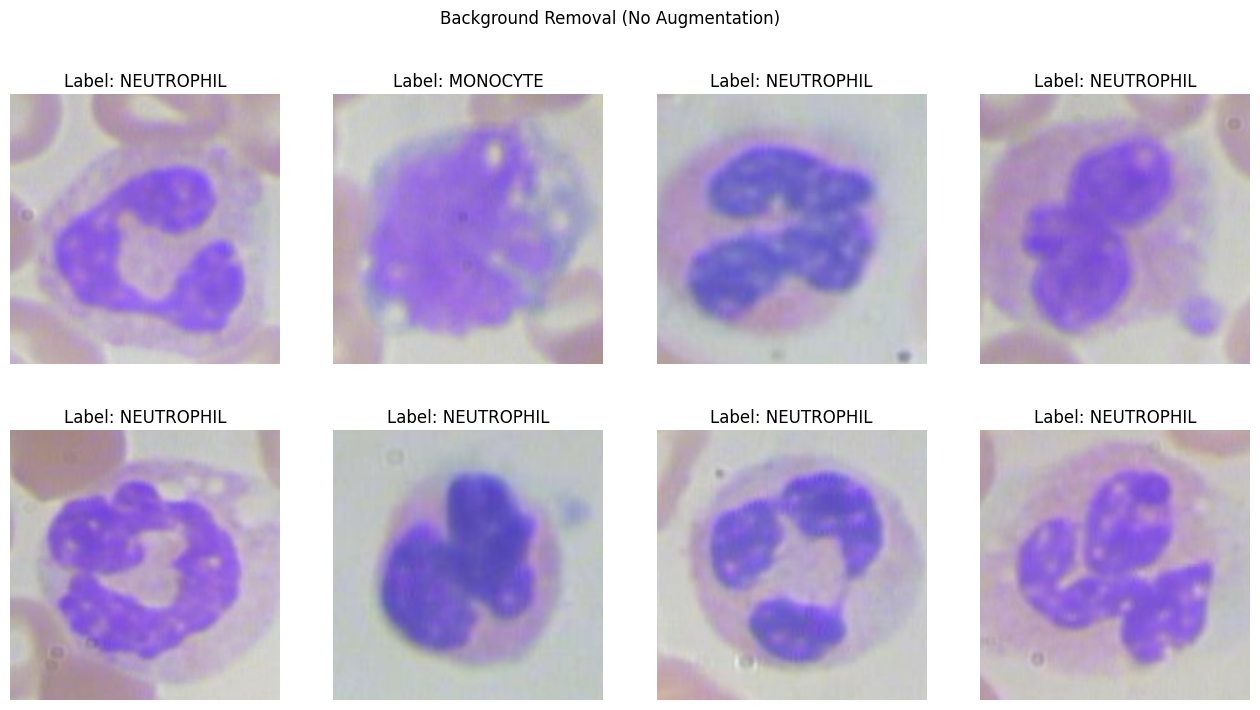

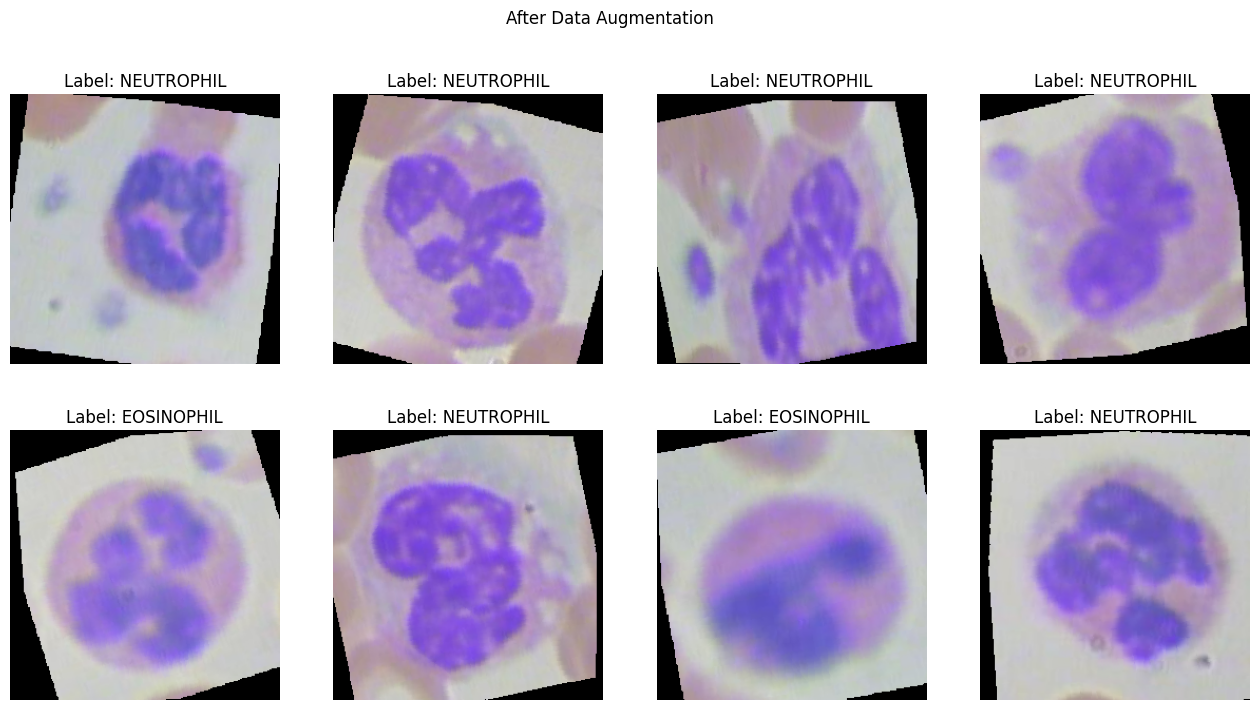

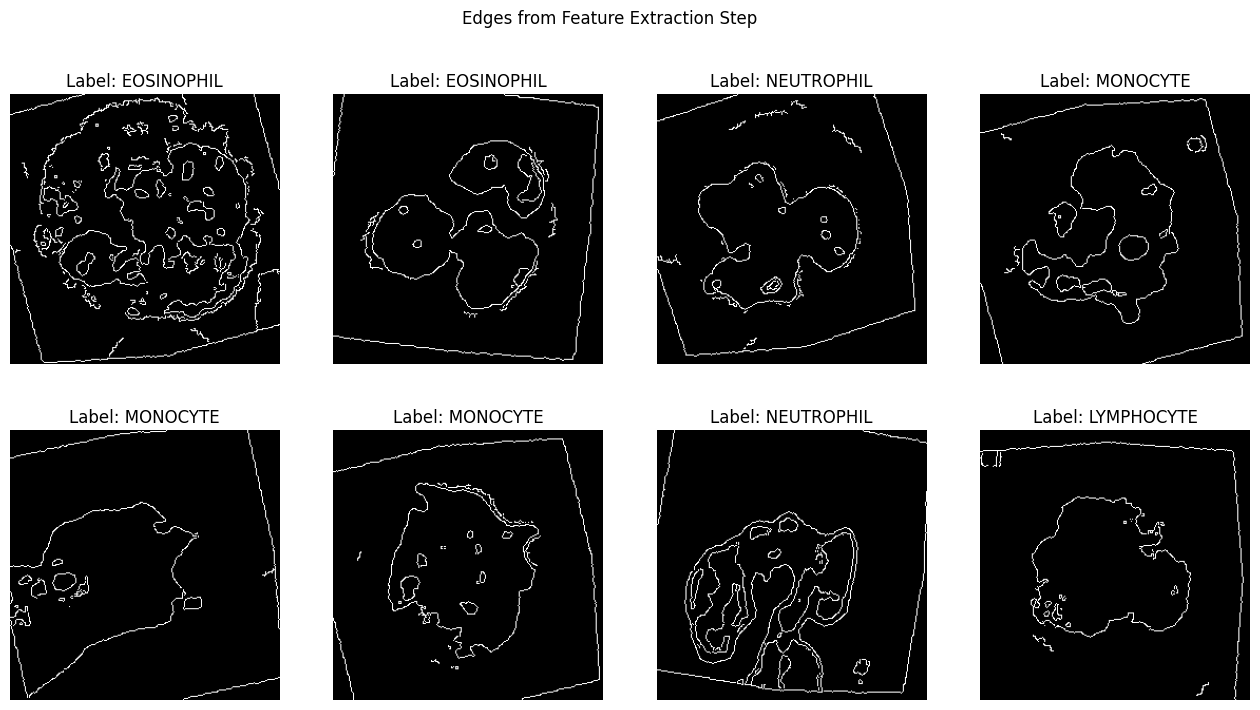

Error loading /kaggle/input/blood-cell-images-based-classification-batch7/Images/Images/BloodImage_00329.jpg: [Errno 2] No such file or directory: '/kaggle/input/blood-cell-images-based-classification-batch7/Images/Images/BloodImage_00329.jpg'
Error loading /kaggle/input/blood-cell-images-based-classification-batch7/Images/Images/BloodImage_00329.jpg: [Errno 2] No such file or directory: '/kaggle/input/blood-cell-images-based-classification-batch7/Images/Images/BloodImage_00329.jpg'

Logistic Regression CV Classifier


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Validation Report:

Logistic Regression Classifier


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Report:

SVM Classifier
Validation Report:

KNN Classifier
Validation Report:

Decision Tree Classifier
Validation Report:

Random Forest Classifier
Validation Report:

XGBoost Classifier
Validation Report:

Gradient Boosting Classifier
Validation Report:

AdaBoost Classifier
Validation Report:

Naive Bayes Classifier
Validation Report:

Balanced Forest Classifier


/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


Validation Report:

Extra Trees Classifier
Validation Report:
Final Predictions:
['NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL'
 'LYMPHOCYTE' 'NEUTROPHIL' 'EOSINOPHIL' 'EOSINOPHIL' 'NEUTROPHIL'
 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'MONOCYTE' 'NEUTROPHIL'
 'NEUTROPHIL' 'NEUTROPHIL' 'EOSINOPHIL' 'EOSINOPHIL' 'EOSINOPHIL'
 'EOSINOPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL'
 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL'
 'EOSINOPHIL' 'NEUTROPHIL' 'MONOCYTE' 'EOSINOPHIL' 'NEUTROPHIL'
 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL'
 'NEUTROPHIL' 'NEUTROPHIL' 'EOSINOPHIL' 'NEUTROPHIL' 'LYMPHOCYTE'
 'EOSINOPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'EOSINOPHIL' 'NEUTROPHIL'
 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'NEUTROPHIL' 'EOSINOPHIL'
 'EOSINOPHIL']


In [8]:
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, Subset, ConcatDataset
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import cv2
from sklearn.linear_model import LogisticRegressionCV
import os
import torch
import random
import matplotlib.pyplot as plt

# ----------------------------
# Process Image Function for Background Removal
# ----------------------------
def process_image(image):
    """
    Process an image (in BGR format) to remove background interference.
    Applies Gaussian blur, HSV thresholding to isolate purple,
    morphological operations, and bitwise masking.
    Returns the processed image in RGB.
    
    blurred = cv2.GaussianBlur(image, (5, 5), 1)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    lower_purple = np.array([120, 50, 50])
    upper_purple = np.array([160, 255, 255])
    mask = cv2.inRange(hsv, lower_purple, upper_purple)
    kernel = np.ones((7, 7), np.uint8)
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    kernel = np.ones((15, 15), np.uint8)
    dilated = cv2.dilate(opened, kernel, iterations=1)
    rgb_mask = cv2.cvtColor(dilated, cv2.COLOR_GRAY2BGR)
    combined = cv2.bitwise_and(rgb_mask, image)
    combined = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)
    return combined"""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    lower_purple = np.array([100, 50, 50])  
    upper_purple = np.array([140, 255, 255])

    mask = cv2.inRange(hsv, lower_purple, upper_purple)


    kernel = np.ones((3, 3), np.uint8)
    eroded_image = cv2.erode(mask, kernel, iterations=3)

    kernel = np.ones((31, 31), np.uint8)  
    expanded_mask = cv2.dilate(eroded_image, kernel, iterations=2)

   
    contours, _ = cv2.findContours(expanded_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

    output_size = (256, 256)  
    if len(sorted_contours) == 0:
        return cv2.resize(image, output_size)


    largest_contour = sorted_contours[0]
    x, y, w, h = cv2.boundingRect(largest_contour)


    cropped_image = image[y:y+h, x:x+w]


    resized_cropped_image = cv2.resize(cropped_image, output_size)

    output_rgb = cv2.cvtColor(resized_cropped_image, cv2.COLOR_BGR2RGB)

    return output_rgb



# ----------------------------
# Custom Dataset Class
# ----------------------------
class ImageDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, is_test=False):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_number = str(self.data.iloc[idx, 0])
        img_name = f"BloodImage_{int(img_number):05d}.jpg"
        img_path = os.path.join(self.img_dir, img_name)

        try:
            # Load image as PIL and convert to RGB
            image = Image.open(img_path).convert("RGB")
            # Convert PIL image to numpy array (RGB)
            image_np = np.array(image)
            # Convert RGB to BGR (for OpenCV processing)
            image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)
            # Process image to remove background interference
            processed_np = process_image(image_bgr)
            # Convert back to PIL Image (RGB)
            image = Image.fromarray(processed_np)
            label = self.data.iloc[idx, 1] if not self.is_test else -1
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return None, None

        if self.transform:
            image = self.transform(image)
        return image, label

# ----------------------------
# Define Transforms with Augmentation
# ----------------------------
# Set random seed for reproducibility
seed_value = 42
torch.manual_seed(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=5,
        translate=(0.05, 0.05),  # Conservative translation
        scale=(0.95, 1.05)       # Slight zoom variation
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ----------------------------
# File Paths & Dataset Initialization
# ----------------------------
img_folder = "/kaggle/input/blood-cell-images-based-classification-batch7/Images/Images"
train_csv = "/kaggle/input/blood-cell-images-based-classification-batch7/train.csv"
test_csv = "/kaggle/input/blood-cell-images-based-classification-batch7/test.csv"

train_dataset = ImageDataset(train_csv, img_folder, train_transform)
test_dataset = ImageDataset(test_csv, img_folder, train_transform, is_test=True)

# ----------------------------
# VISUALIZATION STEP 1: Show 8 random images AFTER background removal but BEFORE augmentation
# ----------------------------
# We do this by creating a temp dataset with transform=None, so we only see background removal
temp_dataset_no_transform = ImageDataset(train_csv, img_folder, transform=None)

def show_background_removal(dataset, num_images=8):
    indices = random.sample(range(len(dataset)), num_images)
    fig, axes = plt.subplots(2, 4, figsize=(16,8))
    for ax, idx in zip(axes.flatten(), indices):
        img, lbl = dataset[idx]
        if img is not None:
            ax.imshow(np.array(img))
            ax.set_title(f"Label: {lbl}")
        ax.axis("off")
    plt.suptitle("Background Removal (No Augmentation)")
    plt.show()

show_background_removal(temp_dataset_no_transform)

# ----------------------------
# VISUALIZATION STEP 2: Show 8 random images AFTER augmentation
# ----------------------------
def show_augmentation(dataset, num_images=8):
    indices = random.sample(range(len(dataset)), num_images)
    fig, axes = plt.subplots(2, 4, figsize=(16,8))
    for ax, idx in zip(axes.flatten(), indices):
        img, lbl = dataset[idx]
        if img is not None:
            # Convert the tensor back to [0,1] range for display
            img_np = img.permute(1, 2, 0).numpy()
            img_np = (img_np * 0.5) + 0.5  # Because we normalized with mean=0.5, std=0.5
            ax.imshow(img_np)
            ax.set_title(f"Label: {lbl}")
        ax.axis("off")
    plt.suptitle("After Data Augmentation")
    plt.show()

show_augmentation(train_dataset)

# Handle class imbalance with enhanced oversampling
labels = [train_dataset.data.iloc[idx, 1] for idx in range(len(train_dataset))]
oversampler = RandomOverSampler(random_state=42)
indices = np.arange(len(train_dataset)).reshape(-1, 1)
oversampled_indices, _ = oversampler.fit_resample(indices, labels)

# Duplicate indices for double augmentation
oversampled_indices = oversampled_indices.squeeze()
duplicated_indices = np.concatenate([oversampled_indices, oversampled_indices])  # Duplicate all samples
oversampled_dataset = Subset(train_dataset, duplicated_indices)

# ----------------------------
# Feature Extraction Function
# ----------------------------
def extract_features(img_tensor):
    """
    Extracts features from an image tensor:
      - Color frequency: 16-bin histograms for each RGB channel (range -1 to 1).
      - Edge detection: total edge pixel count and density.
      - Shape: area of the largest contour from the edge map.
    Returns a 1D numpy array of features.
    """
    # Convert from tensor (C,H,W) to numpy (H,W,C)
    image_np = img_tensor.numpy().transpose(1, 2, 0)
    
    # --- Color Frequency ---
    hist_features = []
    for i in range(3):  # For each channel: R, G, B
        hist, _ = np.histogram(image_np[:, :, i], bins=16, range=(-1, 1))
        hist_features.extend(hist)
    hist_features = np.array(hist_features)  # 48 features

    # --- Edge Detection ---
    gray = cv2.cvtColor((image_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 100)
    edge_count = np.sum(edges > 0)
    edge_density = edge_count / (edges.shape[0] * edges.shape[1])
    edge_features = np.array([edge_count, edge_density])  # 2 features

    # --- Shape Feature ---
    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour_area = max(cv2.contourArea(c) for c in contours)
    else:
        largest_contour_area = 0
    shape_features = np.array([largest_contour_area])  # 1 feature

    # Concatenate all features (48 + 2 + 1 = 51 features)
    features = np.concatenate([hist_features, edge_features, shape_features])
    return features

# ----------------------------
# VISUALIZATION STEP 3: Show the edge map for 8 random images (Feature Extraction Step)
# ----------------------------
def show_feature_extraction(dataset, num_images=8):
    indices = random.sample(range(len(dataset)), num_images)
    fig, axes = plt.subplots(2, 4, figsize=(16,8))
    for ax, idx in zip(axes.flatten(), indices):
        img, lbl = dataset[idx]
        if img is not None:
            # Convert to numpy
            image_np = img.numpy().transpose(1, 2, 0)
            # Gray + edges
            gray = cv2.cvtColor((image_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
            edges = cv2.Canny(gray, 100, 200)
            ax.imshow(edges, cmap='gray')
            ax.set_title(f"Label: {lbl}")
        ax.axis("off")
    plt.suptitle("Edges from Feature Extraction Step")
    plt.show()

show_feature_extraction(oversampled_dataset)

# ----------------------------
# Prepare Data Function using Feature Extraction
# ----------------------------
def prepare_data(dataset):
    features_list, labels_list = [], []
    for img, label in dataset:
        if img is not None and label != -1:
            feat = extract_features(img)
            features_list.append(feat)
            labels_list.append(label)
    return np.array(features_list), np.array(labels_list)

X_train, y_train = prepare_data(oversampled_dataset)

# ----------------------------
# Dimensionality Reduction and Data Splitting
# ----------------------------
pca = PCA(n_components=0.999, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_pca, y_train, test_size=0.01, random_state=42
)
# ----------------------------
# Initialize Classifiers
# ----------------------------
classifiers = [
    ('Logistic Regression CV', LogisticRegressionCV(max_iter=1000)),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('SVM', SVC(kernel='rbf')),
    ('KNN', KNeighborsClassifier(n_neighbors=7)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=50, min_samples_split=2)),
    ('Random Forest', RandomForestClassifier(n_estimators=500, max_depth=50, min_samples_split=2)),
    ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',learning_rate=0.01, max_depth=8, subsample=0.8)),
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('AdaBoost', AdaBoostClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('Balanced Forest', BalancedRandomForestClassifier(n_estimators=500, max_depth=50, min_samples_split=2)),
    ('Extra Trees', ExtraTreesClassifier(n_estimators=500, max_depth=50, min_samples_split=2))
]

# ----------------------------
# Model Training and Evaluation
# ----------------------------
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_split)
y_val_encoded = label_encoder.transform(y_val_split)
model = {}

for name, clf in classifiers:
    print(f"\n{name} Classifier")
    clf.fit(X_train_split, y_train_encoded)
    model[name] = clf
    
    # Validation Report
    y_pred = clf.predict(X_val_split)
    print("Validation Report:")
    #print(classification_report(y_val_encoded, y_pred, target_names=label_encoder.classes_))

# ----------------------------
# Test Data Preparation and Prediction
# ----------------------------
def prepare_test_data(dataset):
    features_list = []
    for img, _ in dataset:
        if img is not None:
            feat = extract_features(img)
            features_list.append(feat)
    return np.array(features_list)

X_test = prepare_test_data(test_dataset)
X_test_pca = pca.transform(X_test)

# Final predictions
best_model = model['Extra Trees']
final_preds = label_encoder.inverse_transform(best_model.predict(X_test_pca))
print("Final Predictions:")
print(final_preds)

In [9]:
from sklearn.metrics import fbeta_score
dataset=pd.read_csv('/kaggle/input/testtt/test (labeled).csv')
y=dataset.iloc[:,-1].values
for name, clf in classifiers:
    print(f"\n{name} Classifier")
    best_model=model[name]
    
    final_preds = label_encoder.inverse_transform(best_model.predict(X_test_pca))
    print(classification_report(y,final_preds))
    print(fbeta_score(y,final_preds,average='micro',beta=1))


Logistic Regression CV Classifier
              precision    recall  f1-score   support

  EOSINOPHIL       0.85      0.77      0.81        22
  LYMPHOCYTE       0.67      1.00      0.80         4
    MONOCYTE       1.00      0.40      0.57         5
  NEUTROPHIL       0.79      0.88      0.83        25

    accuracy                           0.80        56
   macro avg       0.83      0.76      0.75        56
weighted avg       0.82      0.80      0.80        56

0.8035714285714286

Logistic Regression Classifier
              precision    recall  f1-score   support

  EOSINOPHIL       0.81      0.77      0.79        22
  LYMPHOCYTE       0.80      1.00      0.89         4
    MONOCYTE       0.67      0.40      0.50         5
  NEUTROPHIL       0.78      0.84      0.81        25

    accuracy                           0.79        56
   macro avg       0.76      0.75      0.75        56
weighted avg       0.78      0.79      0.78        56

0.7857142857142857

SVM Classifier
         

In [16]:
best_model=model['KNN']
    
final_preds = label_encoder.inverse_transform(best_model.predict(X_test_pca))
print(classification_report(y,final_preds))

              precision    recall  f1-score   support

  EOSINOPHIL       0.87      0.91      0.89        22
  LYMPHOCYTE       0.50      0.50      0.50         4
    MONOCYTE       0.43      0.60      0.50         5
  NEUTROPHIL       1.00      0.88      0.94        25

    accuracy                           0.84        56
   macro avg       0.70      0.72      0.71        56
weighted avg       0.86      0.84      0.85        56



In [17]:
test_df=pd.read_csv('/kaggle/input/blood-cell-images-based-classification-batch7/test.csv')
submission_df = pd.DataFrame({
    'Image': test_df['Image'],  # Use the correct column name
    'Category': final_preds
})
submission_df.to_csv('KNN 22.csv', index=False)
print("Submission file created successfully!")

Submission file created successfully!
